In [ ]:
from pathlib import Path

# All generated figures are written here
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [8]:
len(df)

170

In [4]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("texas_obs_facilities_final.csv")

# Print all column names
print(df.columns)

Index(['ADDRESS', 'ALT_NAME', 'BEDS', 'CITY', 'COUNTRY', 'COUNTY',
       'COUNTYFIPS', 'HELIPAD', 'ID', 'LATITUDE', 'LONGITUDE', 'NAICS_CODE',
       'NAICS_DESC', 'NAME', 'OBJECTID', 'OWNER', 'POPULATION', 'SOURCE',
       'SOURCEDATE', 'STATE', 'STATE_ID', 'STATUS', 'ST_FIPS', 'TELEPHONE',
       'TRAUMA', 'TTL_STAFF', 'TYPE', 'VAL_DATE', 'VAL_METHOD', 'WEBSITE',
       'ZIP', 'ZIP4', 'geometry', 'bbox'],
      dtype='object')


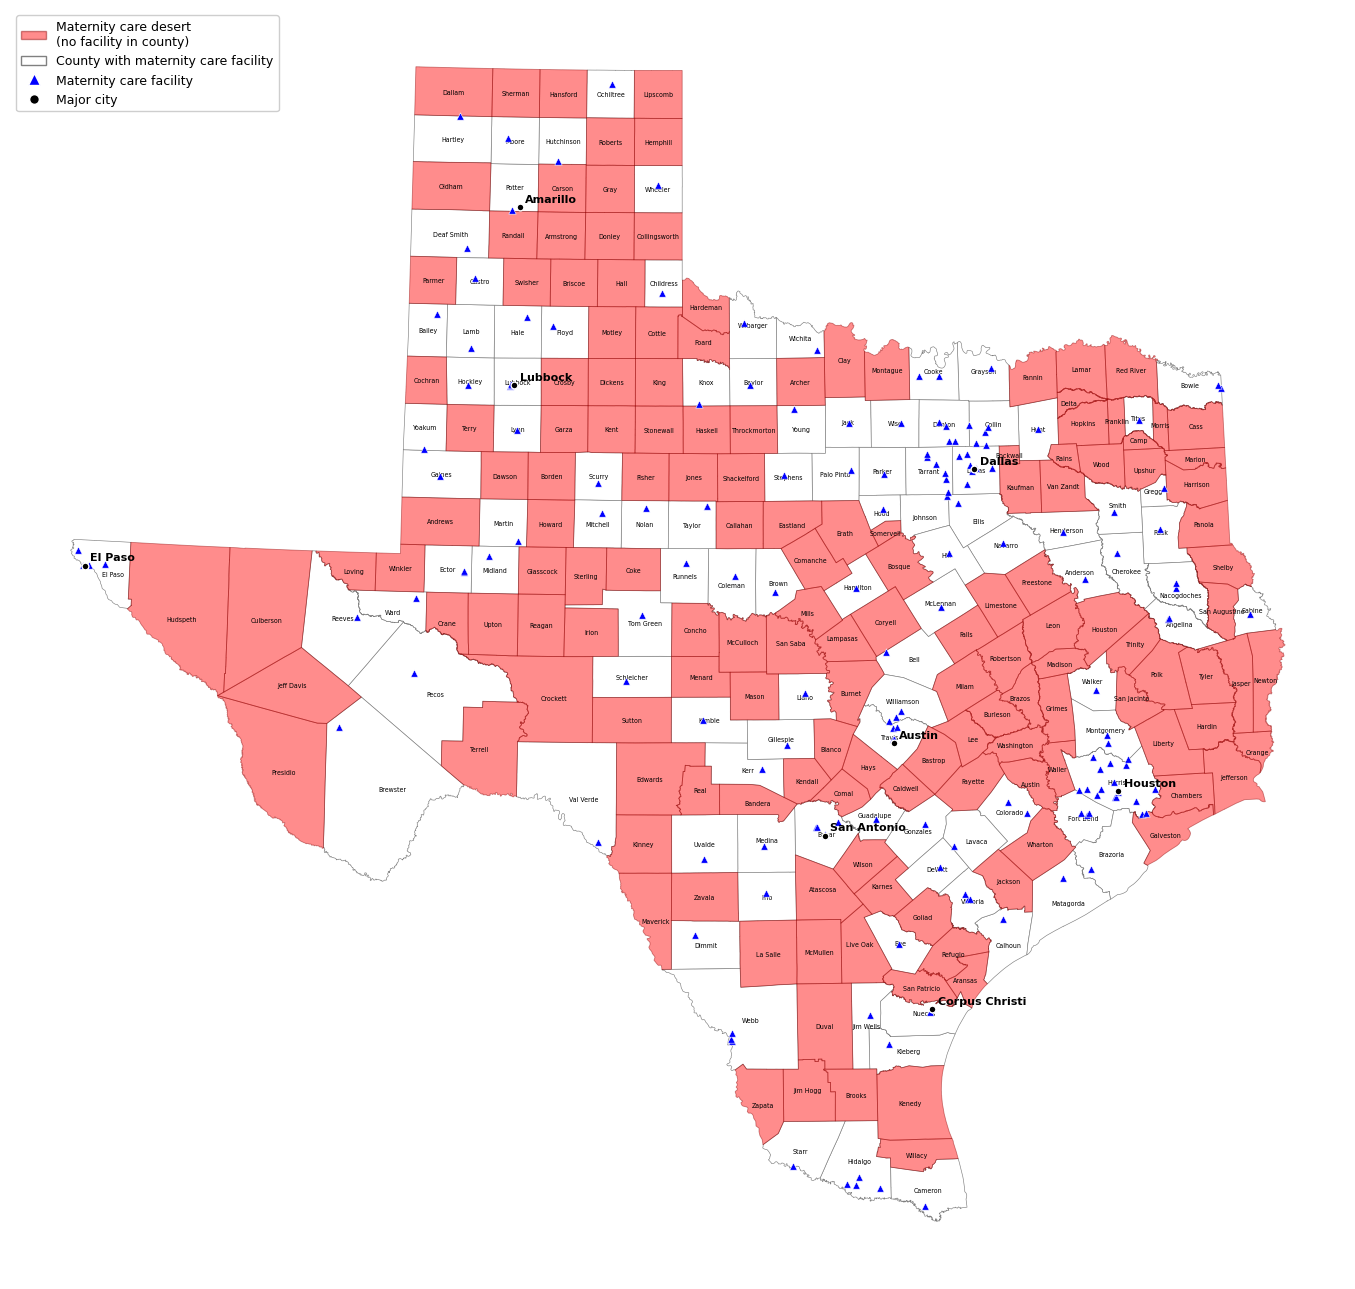

In [20]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --------------------------------------------------
# Major Texas cities and coordinates
# --------------------------------------------------
major_cities = {
    "Houston": (-95.3698, 29.7604),
    "San Antonio": (-98.4936, 29.4241),
    "Dallas": (-96.7970, 32.7767),
    "Austin": (-97.7431, 30.2672),
    #"Fort Worth": (-97.3308, 32.7555),
    "El Paso": (-106.4850, 31.7619),
    #"Arlington": (-97.1081, 32.7357),
    "Corpus Christi": (-97.3964, 27.8006),
    "Lubbock": (-101.8552, 33.5779),
    "Amarillo": (-101.8313, 35.2220)
}

# Use a projected CRS for cleaner plotting and labeling
plot_crs = "EPSG:3083"   # Texas Centric Albers

tx_plot = tx_counties.to_crs(plot_crs)
fac_plot = gdf_fac.to_crs(plot_crs)

# --------------------------------------------------
# Create city GeoDataFrame
# --------------------------------------------------
cities_df = pd.DataFrame(
    [
        {"CITY": city, "LONGITUDE": lon, "LATITUDE": lat}
        for city, (lon, lat) in major_cities.items()
    ]
)

cities_gdf = gpd.GeoDataFrame(
    cities_df,
    geometry=gpd.points_from_xy(
        cities_df["LONGITUDE"],
        cities_df["LATITUDE"]
    ),
    crs="EPSG:4326"
).to_crs(plot_crs)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 13))

# Counties with maternity facilities
tx_plot[tx_plot["HasFacility"]].plot(
    ax=ax,
    color="white",
    edgecolor="gray",
    linewidth=0.45
)

# Counties without maternity facilities:
# maternity care deserts
tx_plot[~tx_plot["HasFacility"]].plot(
    ax=ax,
    color="red",
    alpha=0.45,
    edgecolor="darkred",
    linewidth=0.6
)

# Facility locations
fac_plot.plot(
    ax=ax,
    marker="^",
    color="blue",
    edgecolor="white",
    linewidth=0.4,
    markersize=28,
    zorder=4
)

# --------------------------------------------------
# Add county names
# --------------------------------------------------
county_label_points = tx_plot.geometry.representative_point()

for county_name, point in zip(tx_plot["NAME"], county_label_points):
    ax.annotate(
        county_name,
        xy=(point.x, point.y),
        ha="center",
        va="center",
        fontsize=4.5,
        color="black",
        zorder=3
    )

# --------------------------------------------------
# Add major-city points and names
# --------------------------------------------------
cities_gdf.plot(
    ax=ax,
    marker="o",
    color="black",
    edgecolor="white",
    markersize=24,
    zorder=5
)

for _, city in cities_gdf.iterrows():
    ax.annotate(
        city["CITY"],
        xy=(city.geometry.x, city.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color="black",
        zorder=6
    )

# --------------------------------------------------
# Custom legend
# --------------------------------------------------
legend_items = [
    Patch(
        facecolor="red",
        edgecolor="darkred",
        alpha=0.45,
        label="Maternity care desert\n(no facility in county)"
    ),
    Patch(
        facecolor="white",
        edgecolor="gray",
        label="County with maternity care facility"
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="none",
        markerfacecolor="blue",
        markeredgecolor="white",
        markersize=9,
        label="Maternity care facility"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="black",
        markeredgecolor="white",
        markersize=7,
        label="Major city"
    )
]

ax.legend(
    handles=legend_items,
    loc="upper left",
    #loc=[0.3,0.0],
    fontsize=9,
    #title="Map legend",
    title_fontsize=10,
    frameon=True,
    framealpha=0.95
)

#ax.set_title("Maternity Care Facilities and Facility-Deficient Counties in Texas",fontsize=16,fontweight="bold",pad=15)

ax.set_axis_off()

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "Texas_Maternity_Care_Deserts_Map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
plt.savefig(RESULTS_DIR / "Texas_Maternity_Facilities_Map.pdf",dpi=600,bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

# To Do:
# add red box as maternity care dessert, add county name, add big cities names, add approprite legend, 

Census block polygons and population

Census block centroids

Road network for drive-time/distance calculations

# plot census block centroid to each maternity care facitlity in distance, distance